In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import os
import glob

cesm_folder = '/glade/campaign/cesm/km-scale/archive/'
nodeep_summer = 'cam77_dyamond1_prod1/atm/hist'
clubb_summer = 'c124_dyamond1_prod2/atm/hist'

stream = 'h1i' # daily accumulated. other options are h0i, h1i, h2i
timestep = '2016-08-01-00000' # ONE timestep per file !!

filename = f'cam77_dyamond1_prod1.cam.{stream}.{timestep}.nc' 

filepath = os.path.join(cesm_folder, nodeep_summer, filename)

ds = xr.open_dataset(filepath)

ds

<xarray.Dataset> Size: 964GB
Dimensions:           (ncol: 41943042, nCells: 41943042, nVertices: 83886080,
                       trop_pref: 58, trop_prefi: 59, lev: 58, ilev: 59,
                       trop_cld_lev: 58, time: 1)
Coordinates:
  * trop_pref         (trop_pref) float64 464B 2.513 4.453 7.482 ... 987.5 995.9
  * trop_prefi        (trop_prefi) float64 472B 1.755 3.27 5.636 ... 991.7 1e+03
  * lev               (lev) float64 464B 4.112e+04 3.687e+04 ... 106.2 35.0
  * ilev              (ilev) float64 472B 4.343e+04 3.88e+04 ... 70.0 0.0
  * trop_cld_lev      (trop_cld_lev) float64 464B 4.112e+04 3.687e+04 ... 35.0
  * time              (time) object 8B 2016-08-01 00:00:00
Dimensions without coordinates: ncol, nCells, nVertices
Data variables: (12/268)
    lat               (ncol) float64 336MB ...
    lon               (ncol) float64 336MB ...
    areawt            (ncol) float64 336MB ...
    area              (ncol) float64 336MB ...
    latCell           (nCells) float64 336MB ...
    lonCell           (nCells) float64 336MB ...
    ...                ...
    UPWP_CLUBB        (time, ilev, ncol) float32 10GB ...
    VPWP_CLUBB        (time, ilev, ncol) float32 10GB ...
    WP2_CLUBB         (time, ilev, ncol) float32 10GB ...
    WPTHLP_CLUBB      (time, ilev, ncol) float32 10GB ...
    WPRTP_CLUBB       (time, ilev, ncol) float32 10GB ...
    w                 (time, ilev, nCells) float32 10GB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              cam77_dyamond1_prod1
    logname:           aherring
    host:              dec0644
    initial_file:      /glade/campaign/cgd/amp/aherring/mpasa3p75/inic/betaca...
    topography_file:   /glade/campaign/cgd/amp/aherring/mpasa3p75/topo/mpasa3...
    model_doi_url:     not_set
    time_period_freq:  hour_3

In [2]:
def make_grid(res):
    """Regular lat-lon edges for a given resolution in degrees."""
    lon_edges = np.arange(0, 360 + res, res)
    lat_edges = np.arange(-90, 90 + res, res)
    return lon_edges, lat_edges

def coarse_grain_dataset(ds, varlist, res, col_dim="ncol", area_var="area"):
    lon_edges, lat_edges = make_grid(res)
    nlon, nlat = len(lon_edges) - 1, len(lat_edges) - 1

    # grid-only quantities: computed once, reused for every variable
    ilon = np.clip(np.digitize(ds.lon.values, lon_edges) - 1, 0, nlon - 1)
    ilat = np.clip(np.digitize(ds.lat.values, lat_edges) - 1, 0, nlat - 1)
    flat = ilat * nlon + ilon

    w   = np.asarray(ds[area_var].values).ravel()
    den = np.bincount(flat, weights=w, minlength=nlat * nlon)

    lon_centers = 0.5 * (lon_edges[:-1] + lon_edges[1:])
    lat_centers = 0.5 * (lat_edges[:-1] + lat_edges[1:])

    def coarse_last(arr):
        """arr: (..., ncol) -> (..., nlat, nlon), any number of leading dims."""
        lead = arr.shape[:-1]
        arr2 = arr.reshape(-1, arr.shape[-1])           # (batch, ncol)
        out  = np.empty((arr2.shape[0], nlat * nlon))
        for i in range(arr2.shape[0]):
            out[i] = np.bincount(flat, weights=w * arr2[i],
                                 minlength=nlat * nlon) / den
        return out.reshape(*lead, nlat, nlon)

    results = {}
    for name in varlist:
        da = ds[name]
        if col_dim not in da.dims:
            print(f"skipping {name!r}: no {col_dim!r} dimension")
            continue
        other_dims = [d for d in da.dims if d != col_dim]
        da = da.transpose(*other_dims, col_dim)         # ensure ncol is last
        arr = coarse_last(da.values)

        coords = {d: ds[d].values for d in other_dims if d in ds.coords}
        coords["lat"] = lat_centers
        coords["lon"] = lon_centers
        results[name] = xr.DataArray(
            arr, dims=(*other_dims, "lat", "lon"),
            coords=coords, attrs=dict(da.attrs),
        )

    return xr.Dataset(results)

## Variables


## PTTEND AND PTEQ - for lumped approach

#### Vertical Advection / Resolved Transport
DTCORE
DQCORE

#### Microphysics
MPDT, MPDQ, MPDICE, MPDLIQ, EVAPPREC, EVAPSNOW

#### Radiative heating
QRL, QRS

#### Turbulent diffusivity (RF-diff output)
KVH_CLUBB (on interfaces)

#### Turbulent fluxes / tendencies
WPTHLP_CLUBB, WPRTP_CLUBB, DTV, STEND/RVMTEND/RCMTEND_CLUBB

#### Surface fluxes	
SHFLX, LHFLX, QFLX, TAUX, TAUY

#### State for hL, qT, qp + inputs	
T, Q, CLDLIQ, CLDICE, RAINQM, SNOWQM, GRAUQM, U, V, Z3, PMID


#### Surface / geography inputs	
SST, LANDFRAC, OCNFRAC, ICEFRAC, PHIS, SOLIN

These are the inputs the 2020 paper said you'd need to replace the distance-to-equator proxy once symmetry is gone.


#### DO WE HAVE RESOLVED-FROM-COARSE TENDENCIES? NEED THIS TO REPLICATE YOG20, otherwise i can still do it but it may be less stable.

In [4]:
ds["PTTEND"]



<xarray.DataArray 'PTTEND' (time: 1, lev: 58, ncol: 41943042)> Size: 10GB
[2432696436 values with dtype=float32]
Coordinates:
  * lev      (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
  * time     (time) object 8B 2016-08-01 00:00:00
Dimensions without coordinates: ncol
Attributes:
    mdims:         3
    units:         K/s
    long_name:     T total physics tendency
    cell_methods:  time: point

In [5]:
latlon = ['lat', 'lon']
inputs = ['T', 'Q', 'U', 'V', 'SST', 'LANDFRAC']
targets = ['PTTEND', 'PTEQ']

vars = inputs+targets+latlon
ds[vars]

<xarray.Dataset> Size: 59GB
Dimensions:   (time: 1, lev: 58, ncol: 41943042)
Coordinates:
  * lev       (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
  * time      (time) object 8B 2016-08-01 00:00:00
Dimensions without coordinates: ncol
Data variables:
    T         (time, lev, ncol) float32 10GB ...
    Q         (time, lev, ncol) float32 10GB ...
    U         (time, lev, ncol) float32 10GB ...
    V         (time, lev, ncol) float32 10GB ...
    SST       (time, ncol) float32 168MB ...
    LANDFRAC  (time, ncol) float32 168MB ...
    PTTEND    (time, lev, ncol) float32 10GB ...
    PTEQ      (time, lev, ncol) float32 10GB ...
    lat       (ncol) float64 336MB ...
    lon       (ncol) float64 336MB ...
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              cam77_dyamond1_prod1
    logname:           aherring
    host:              dec0644
    initial_file:      /glade/campaign/cgd/amp/aherring/mpasa3p75/inic/betaca...
    topography_file:   /glade/campaign/cgd/amp/aherring/mpasa3p75/topo/mpasa3...
    model_doi_url:     not_set
    time_period_freq:  hour_3

In [6]:
ds_1deg = coarse_grain_dataset(ds, inputs+targets, res=1.0)
ds_1deg

/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = np.bincount(flat, weights=w * arr2[i],
/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = np.bincount(flat, weights=w * arr2[i],
/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = np.bincount(flat, weights=w * arr2[i],
/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = np.bincount(flat, weights=w * arr2[i],
/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = np.bincount(flat, weights=w * arr2[i],
/glade/derecho/scratch/sarahryu/tmp/ipykernel_119339/1202437607.py:28: RuntimeWarning: invalid value encountered in divide
  out[i] = n

<xarray.Dataset> Size: 181MB
Dimensions:   (time: 1, lev: 58, lat: 180, lon: 360)
Coordinates:
  * time      (time) object 8B 2016-08-01 00:00:00
  * lev       (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
  * lat       (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon       (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    T         (time, lev, lat, lon) float64 30MB 249.2 249.1 ... 275.0 274.9
    Q         (time, lev, lat, lon) float64 30MB 3.853e-06 ... 0.004304
    U         (time, lev, lat, lon) float64 30MB -19.23 -21.55 ... 8.002 7.74
    V         (time, lev, lat, lon) float64 30MB 5.439 6.267 ... -1.669 -1.72
    SST       (time, lat, lon) float64 518kB 273.1 273.1 273.1 ... 271.4 271.4
    LANDFRAC  (time, lat, lon) float64 518kB 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    PTTEND    (time, lev, lat, lon) float64 30MB -0.0003627 ... -0.0005086
    PTEQ      (time, lev, lat, lon) float64 30MB 2.025e-14 ... -2.852e-07

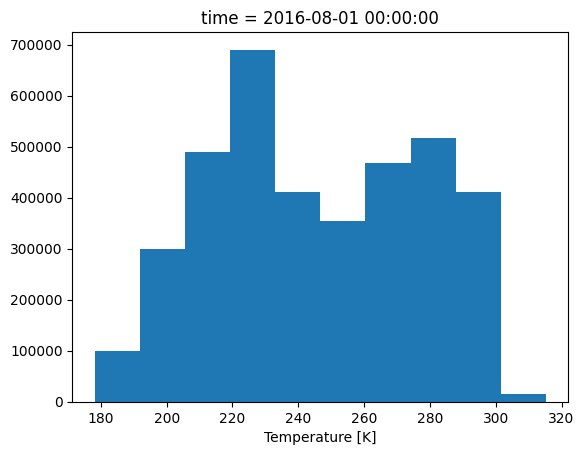

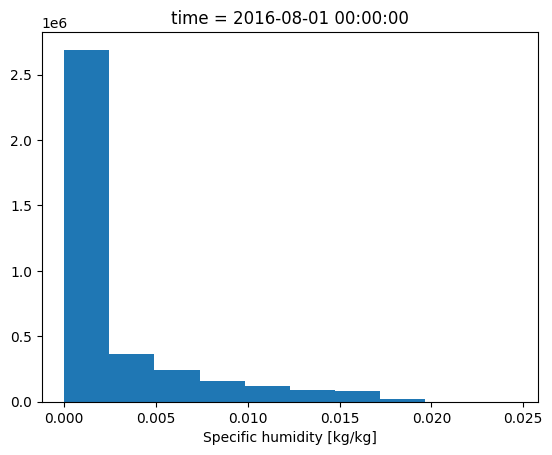

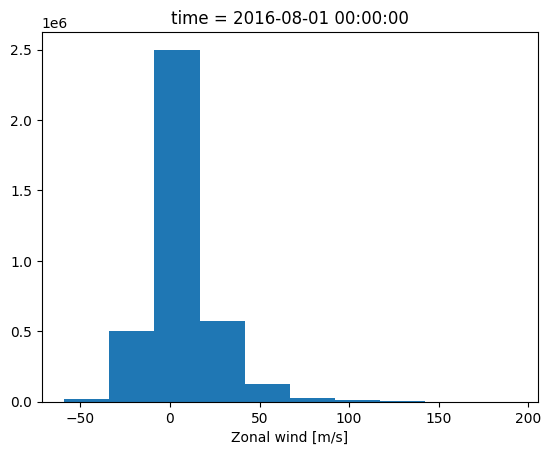

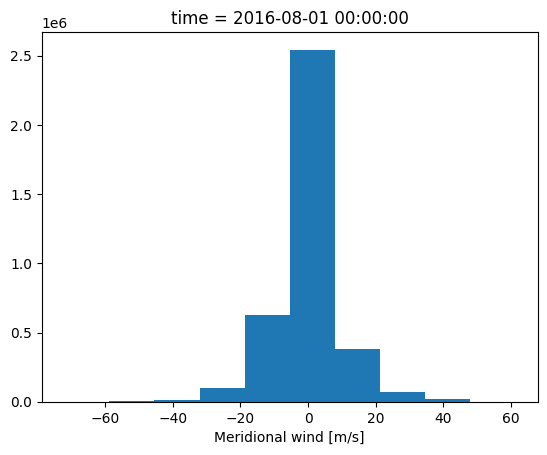

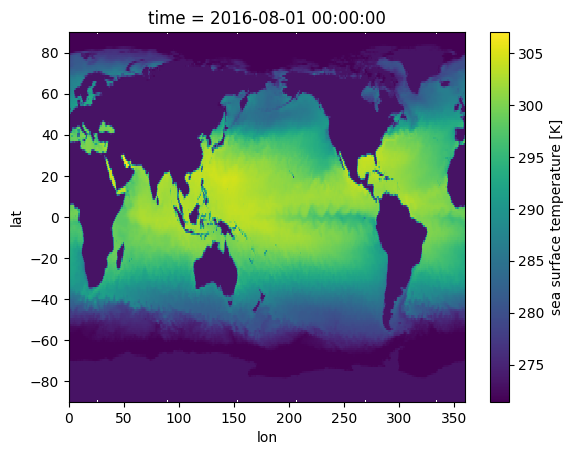

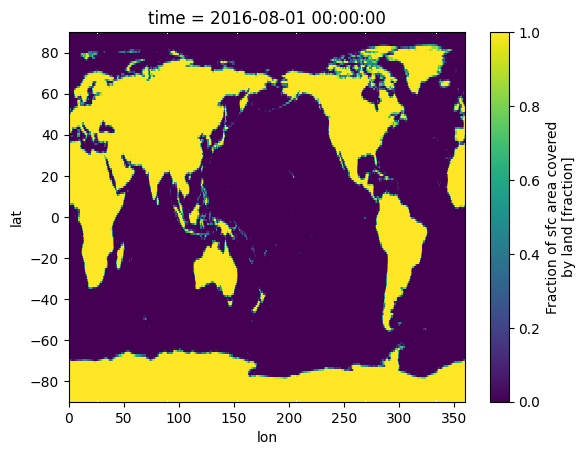

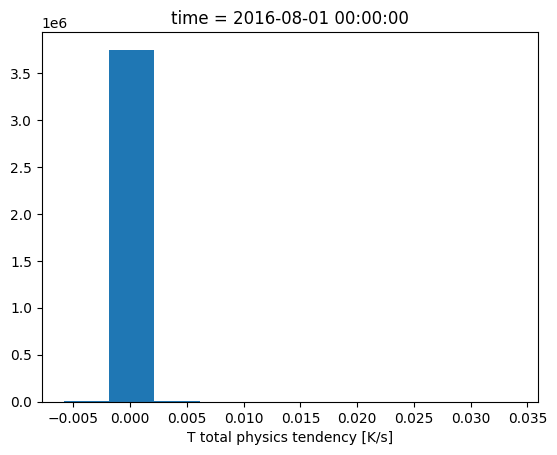

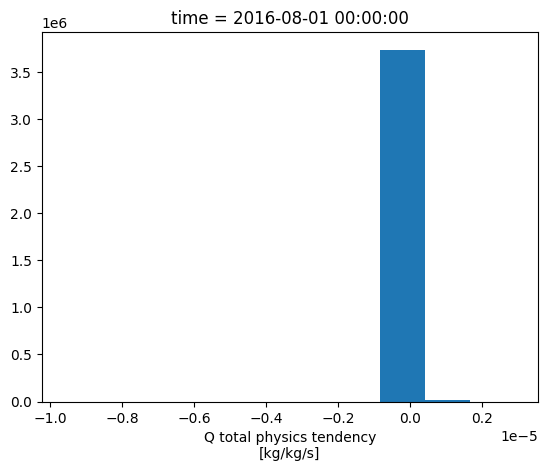

In [7]:
import matplotlib.pyplot as plt

for var in inputs+targets:
    ds_1deg[var].plot()
    plt.show()

In [13]:
ds_1deg[targets]

<xarray.Dataset> Size: 60MB
Dimensions:  (time: 1, lev: 58, lat: 180, lon: 360)
Coordinates:
  * time     (time) object 8B 2016-08-01 00:00:00
  * lev      (lev) float64 464B 4.112e+04 3.687e+04 3.323e+04 ... 106.2 35.0
  * lat      (lat) float64 1kB -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
  * lon      (lon) float64 3kB 0.5 1.5 2.5 3.5 4.5 ... 356.5 357.5 358.5 359.5
Data variables:
    PTTEND   (time, lev, lat, lon) float64 30MB -0.0003627 ... -0.0005086
    PTEQ     (time, lev, lat, lon) float64 30MB 2.025e-14 ... -2.852e-07

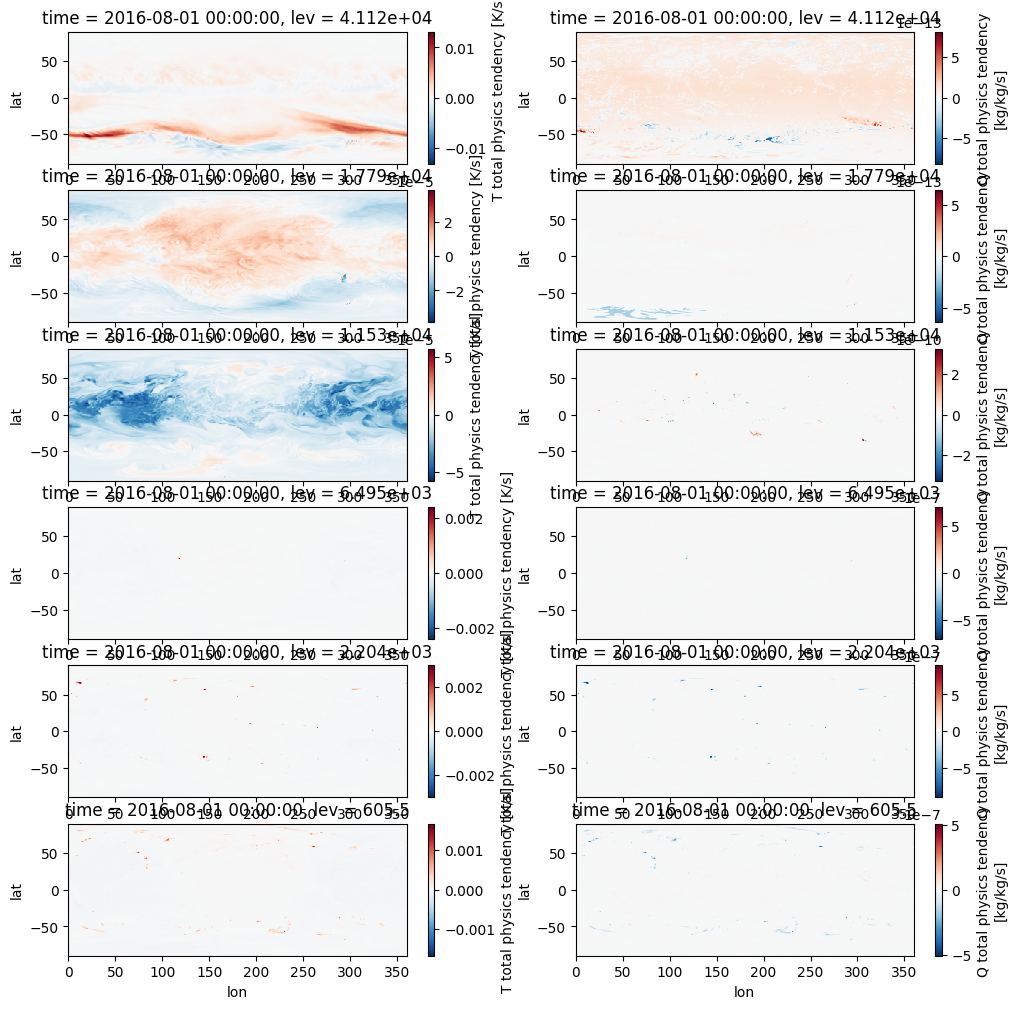

In [15]:
fig, axes = plt.subplots(6,2, figsize=(12,12))

for i in range(2):
    for j in range(6):
        ds_1deg.isel(lev=(j*10))[targets[i]].plot(ax=axes[j,i])


plt.show()

In [ ]:
### TASKS : compare nodeep vs deep, compare summer vs winter. look at diff variables. simple RF plus sensitivity test


### WHAT DOES IT LOOK LIKE COARSE GRAINED?

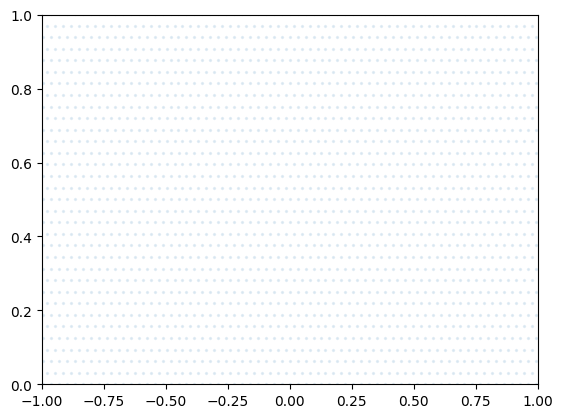

In [7]:
import matplotlib.pyplot as plt

ds_sel = ds.isel(lev=0)[['lat', 'lon', 'T']]#.values
plt.scatter(ds_sel['lat'], ds_sel['lon'], s=2, alpha=0.1)
plt.xlim(-1, 1)
plt.ylim(0, 1)
plt.show()